Loading the dataset.

In [6]:
import os
import sys

import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.callbacks import (
    EarlyStopping,
    ReduceLROnPlateau,
    ModelCheckpoint,
)
from sklearn.utils.class_weight import compute_class_weight

sys.path.insert(0, os.path.abspath(".."))

from src.data_loader import build_datasets

In [7]:
IMG_SIZE = (224, 224)
INPUT_SHAPE = (224, 224, 3)
BATCH_SIZE = 32
EPOCHS = 20
LEARNING_RATE = 1e-5

SPLITS_DIR = "../data/splits"
PROCESSED_DIR = "../data/processed"
BEST_MODEL_PATH = "best_resnet50_preprocessed.keras"


In [8]:
train_ds, val_ds, test_ds, NUM_CLASSES = build_datasets(
    splits_dir=SPLITS_DIR,
    img_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    augment_train=True,      # augmentation already handled in data_loader.py
    use_processed=True,      # use resized images from processed folder
    processed_dir=PROCESSED_DIR
)

print(f"Dataset loaded with {NUM_CLASSES} classes.")


Dataset loaded with 23 classes.


Model is built using a pretrained ResNet50 architecture, initialized with weights from ImageNet. I

- The majority of the layers are not trainable, to keep a pretrained knowledge, and the top 20 layers are allowed to adapt to the new dataset.
- Batch Normalization layers are kept frozen to maintain stable feature distributions during training
- Global Average Pooling to reduce dimensions
- Dropout was applied to prevent overfitting 
- Dense layer with softmax activation produces class probabilities for the target categories


In [9]:
def build_resnet50_model(input_shape=(224, 224, 3), num_classes=23):
    base_model = tf.keras.applications.ResNet50(
        include_top=False,
        weights="imagenet",
        input_shape=input_shape
    )

    # Partial fine-tuning
    base_model.trainable = True

    # Freeze most layers
    for layer in base_model.layers[:-20]:
        layer.trainable = False

    # Unfreeze top layers except BatchNorm
    for layer in base_model.layers[-20:]:
        if isinstance(layer, layers.BatchNormalization):
            layer.trainable = False
        else:
            layer.trainable = True

    inputs = keras.Input(shape=input_shape)

    # Input images from data_loader are in [0,1]
    # ResNet50 preprocess_input expects [0,255]-style input
    x = layers.Rescaling(255.0)(inputs)
    x = layers.Lambda(tf.keras.applications.resnet50.preprocess_input)(x)

    x = base_model(x, training=False)
    x = layers.GlobalAveragePooling2D()(x)
    x = layers.Dropout(0.3)(x)
    outputs = layers.Dense(num_classes, activation="softmax")(x)

    model = keras.Model(inputs, outputs, name="model_resnet50")
    return model, base_model


In [10]:
model_1, base_model_1 = build_resnet50_model(
    input_shape=INPUT_SHAPE,
    num_classes=NUM_CLASSES
)

We have added Callbacks to improve the training process automatically while the model is learning.



- Stop training early
 if the model stops improving (prevents overfitting)
- Adjust learning rate
 make learning slower when needed to improve accuracy
- Save the best model
 keep the best version even if later training gets worse

In [11]:
callbacks_model_1 = [
    EarlyStopping(
        monitor="val_loss",
        patience=4,
        restore_best_weights=True,
        verbose=1
    ),
    ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.5,
        patience=2,
        min_lr=1e-7,
        verbose=1
    ),
    ModelCheckpoint(
        BEST_MODEL_PATH,
        monitor="val_loss",
        save_best_only=True,
        mode="min",
        verbose=1
    )
]

In [12]:
model_1.summary()


Model: "model_resnet50"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ rescaling (Rescaling)           │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lambda (Lambda)                 │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ resnet50 (Functional)           │ (None, 7, 7, 2048)     │    23,587,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 2048)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 23)             │        47,127 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 23,634,839 (90.16 MB)

 Trainable params: 8,966,167 (34.20 MB)

 Non-trainable params: 14,668,672 (55.96 MB)

In [13]:
model_1.compile(
    optimizer=keras.optimizers.Adam(learning_rate=LEARNING_RATE),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

In [14]:
history_1 = model_1.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS,
    callbacks=callbacks_model_1
)


Epoch 1/20
292/292 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.0947 - loss: 3.3649
Epoch 1: val_loss improved from None to 2.05596, saving model to best_resnet50_preprocessed.keras

Epoch 1: finished saving model to best_resnet50_preprocessed.keras
292/292 ━━━━━━━━━━━━━━━━━━━━ 534s 2s/step - accuracy: 0.1662 - loss: 2.9712 - val_accuracy: 0.4048 - val_loss: 2.0560 - learning_rate: 1.0000e-05
Epoch 2/20
292/292 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.4124 - loss: 2.0274
Epoch 2: val_loss improved from 2.05596 to 1.36683, saving model to best_resnet50_preprocessed.keras

Epoch 2: finished saving model to best_resnet50_preprocessed.keras
292/292 ━━━━━━━━━━━━━━━━━━━━ 578s 2s/step - accuracy: 0.4524 - loss: 1.8676 - val_accuracy: 0.6042 - val_loss: 1.3668 - learning_rate: 1.0000e-05
Epoch 3/20
292/292 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.5808 - loss: 1.4173
Epoch 3: val_loss improved from 1.36683 to 1.13983, saving model to best_resnet50_preprocessed.keras

Epoch 3: finishe

In [16]:
best_model_1 = keras.models.load_model(
    BEST_MODEL_PATH,
    custom_objects={
        "preprocess_input": tf.keras.applications.resnet50.preprocess_input
    }
)

In [17]:
test_loss_1, test_acc_1 = best_model_1.evaluate(test_ds, verbose=1)
print(f"Best Model Test Loss: {test_loss_1:.4f}")
print(f"Best Model Test Accuracy: {test_acc_1:.4f}")

63/63 ━━━━━━━━━━━━━━━━━━━━ 96s 1s/step - accuracy: 0.7463 - loss: 0.9251
Best Model Test Loss: 0.9251
Best Model Test Accuracy: 0.7463


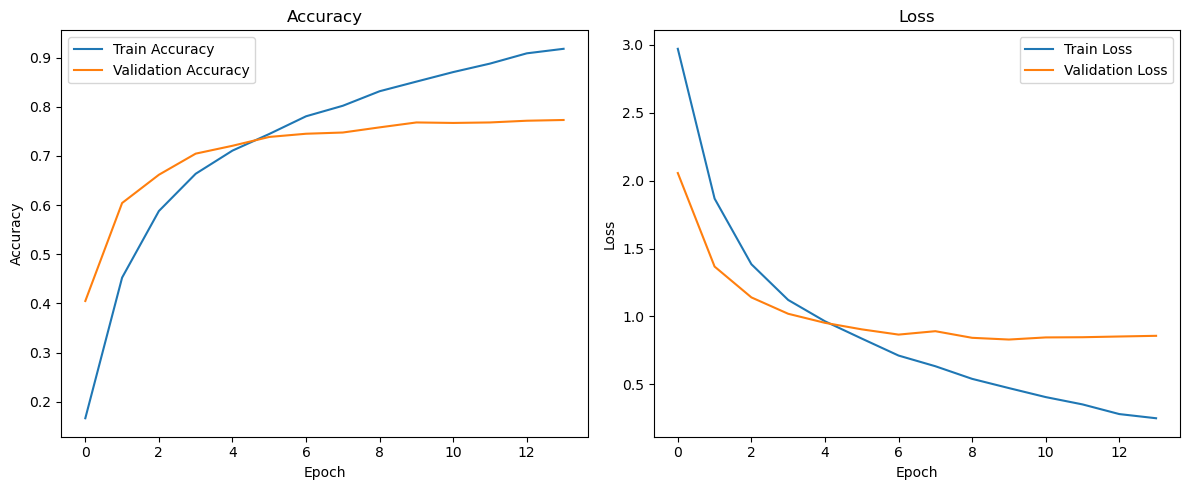

In [18]:
def plot_history(history):
    plt.figure(figsize=(12, 5))

    # Accuracy
    plt.subplot(1, 2, 1)
    plt.plot(history.history["accuracy"], label="Train Accuracy")
    plt.plot(history.history["val_accuracy"], label="Validation Accuracy")
    plt.title("Accuracy")
    plt.xlabel("Epoch")
    plt.ylabel("Accuracy")
    plt.legend()

    # Loss
    plt.subplot(1, 2, 2)
    plt.plot(history.history["loss"], label="Train Loss")
    plt.plot(history.history["val_loss"], label="Validation Loss")
    plt.title("Loss")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.legend()

    plt.tight_layout()
    plt.show()


plot_history(history_1)

The model achieved approximately 77% validation accuracy, demonstrating strong performance. Training was stable with decreasing validation loss. A moderate gap between training and validation accuracy indicates overfitting, but overall generalization remains good.